# Project Goal

To automatically classify boat types using deep learning

#  Part 1: Build a CNN From Scratch

In [56]:
# Mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
# load dataset
import zipfile
zip_ref = zipfile.ZipFile("/content/drive/MyDrive/Boat_dataset_deep_learning/Automating Port Operations_Dataset.zip", 'r')
zip_ref.extractall("/content")
zip_ref.close()

In [58]:
import tensorflow as tf

# Splitting dataset

In [59]:
import os
import random
import shutil
from tqdm import tqdm

# Parameters
original_dataset_dir = '/content/Automating Port Operations_Dataset/boat_type_classification_dataset'  # path to your current image folders
output_base_dir = '/content/Automating Port Operations_Dataset'     # new directory for train/val/test
split_ratio = (0.8, 0.2)  # train, test
seed = 43

# Ensure reproducibility
random.seed(seed)

# Create output folders
splits = ['train', 'test']
for split in splits:
    for class_name in os.listdir(original_dataset_dir):
        os.makedirs(os.path.join(output_base_dir, split, class_name), exist_ok=True)

# Split and copy files
for class_name in tqdm(os.listdir(original_dataset_dir), desc="Splitting dataset"):
    class_dir = os.path.join(original_dataset_dir, class_name)
    images = os.listdir(class_dir)
    random.shuffle(images)

    total = len(images)
    train_cut = int(split_ratio[0] * total)
    val_cut = int(split_ratio[1] * total)

    train_files = images[:train_cut]
    val_files = images[train_cut:train_cut + val_cut]
    test_files = images[train_cut + val_cut:]

    for split_name, file_list in zip(splits, [train_files, val_files, test_files]):
        for fname in file_list:
            src = os.path.join(class_dir, fname)
            dst = os.path.join(output_base_dir, split_name, class_name, fname)
            shutil.copy(src, dst)

print("Dataset split completed!")


Splitting dataset: 100%|██████████| 9/9 [00:00<00:00, 15.36it/s]

Dataset split completed!


In [60]:
train_path = '/content/Automating Port Operations_Dataset/train'
test_path = '/content/Automating Port Operations_Dataset/test'

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    seed=43,
    shuffle=True,
    image_size=(224, 224),
    batch_size=32
)


test_ds=tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    seed=43,
    shuffle=True,
    image_size=(224,224),
    batch_size=32
)

Found 925 files belonging to 9 classes.
Found 228 files belonging to 9 classes.


In [61]:
925+237

1162

# Visualize Number of Images per Class in the Train Set

In [62]:
import os
import matplotlib.pyplot as plt

In [63]:
# Get class names (folder names) and count images in each
class_counts = {}
for class_name in os.listdir(train_path):
    class_path = os.path.join(train_path, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))


In [64]:
print( os.listdir(train_path))

['cruise_ship', 'ferry_boat', 'sailboat', 'inflatable_boat', 'kayak', 'paper_boat', 'gondola', 'freight_boat', 'buoy']


In [65]:
class_counts

{'cruise_ship': 152,
 'ferry_boat': 50,
 'sailboat': 311,
 'inflatable_boat': 12,
 'kayak': 162,
 'paper_boat': 24,
 'gondola': 154,
 'freight_boat': 18,
 'buoy': 42}

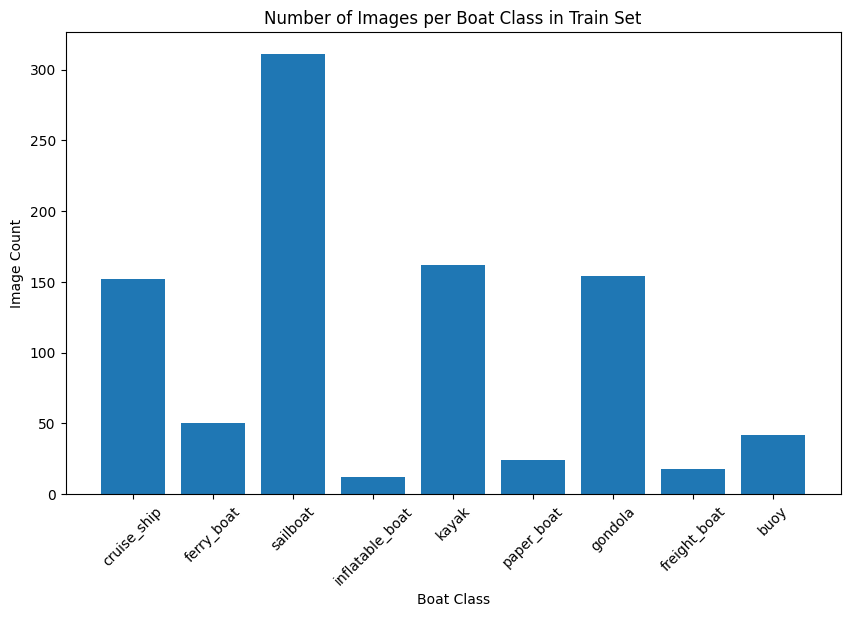

In [66]:
# Plotting
plt.figure(figsize=(10, 6))
plt.bar(class_counts.keys(), class_counts.values())
plt.title('Number of Images per Boat Class in Train Set')
plt.xlabel('Boat Class')
plt.ylabel('Image Count')
plt.xticks(rotation=45)
plt.show()

# Visualize 1 Image per Class

In [67]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

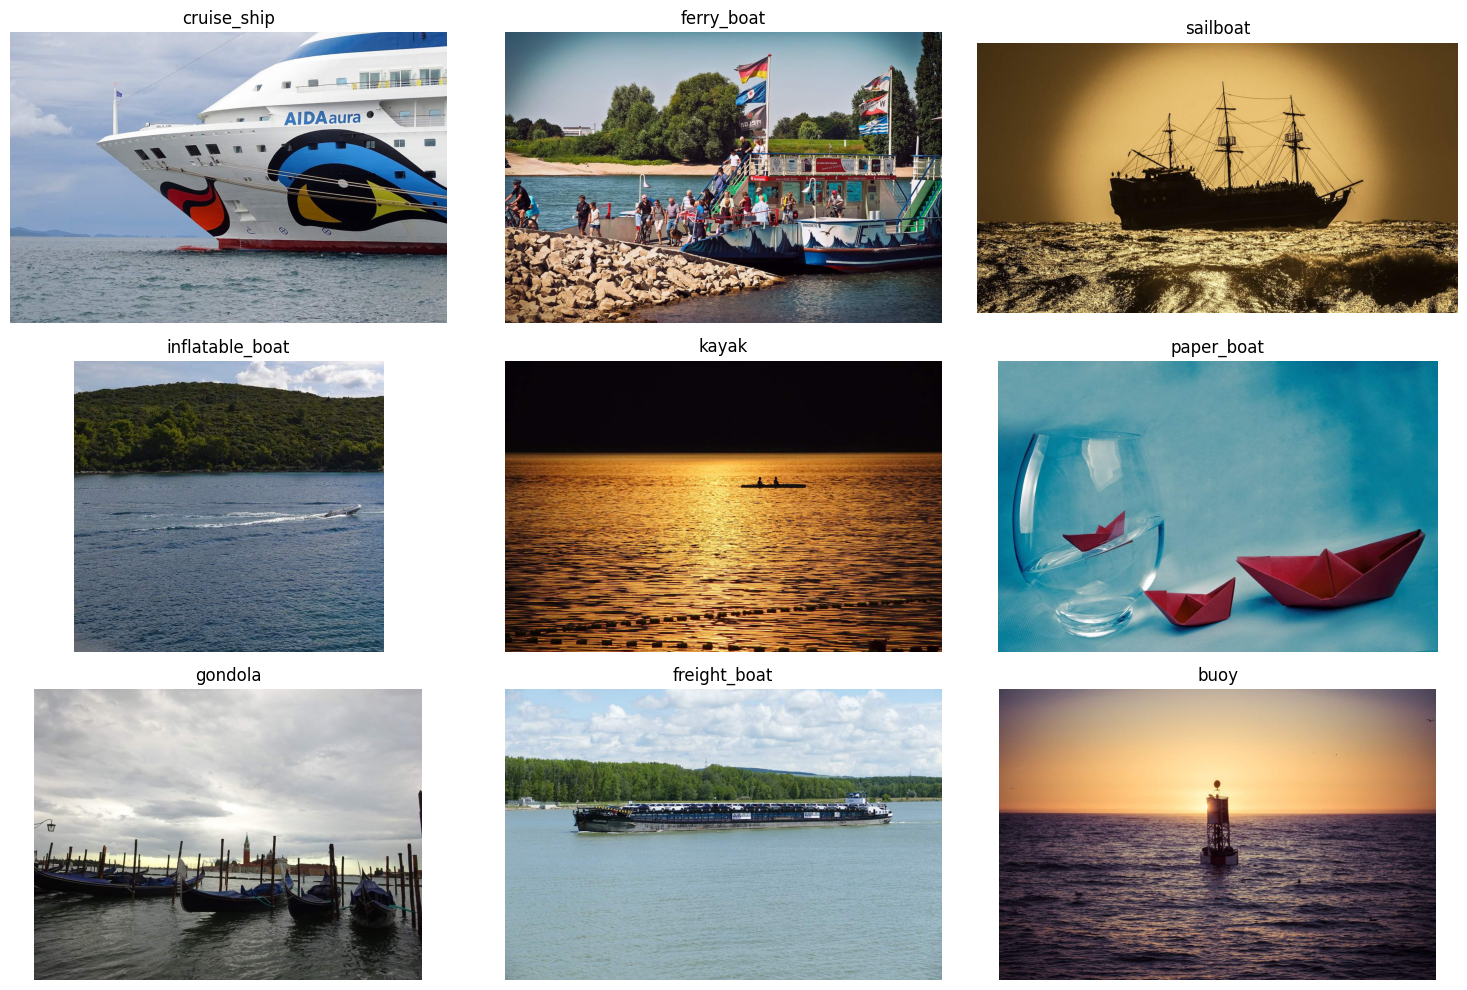

In [68]:
# Visualize 1 image per class
plt.figure(figsize=(15, 10))

for i, class_name in enumerate(os.listdir(train_path)):
    class_dir = os.path.join(train_path, class_name)
    img_name = os.listdir(class_dir)[0]  # get first image
    img_path = os.path.join(class_dir, img_name)

    img = mpimg.imread(img_path)
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Data Augmentation/ Data Preprocessing

In [69]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [70]:
train_datagen=ImageDataGenerator(rescale=1./255,
                                 shear_range=0.2,
                                 zoom_range=0.2,
                                 width_shift_range=0.1,
                                height_shift_range=0.1,
                                 horizontal_flip=True)

test_datagen=ImageDataGenerator(rescale=1./255)

# Create Train data and  Test data

In [71]:
training_set=train_datagen.flow_from_directory(train_path,
                                               target_size=(224,224),
                                               batch_size=32,
                                               class_mode='categorical')

test_set=test_datagen.flow_from_directory(test_path,
                                          target_size=(224,224),
                                          batch_size=32,
                                          class_mode='categorical')

Found 925 images belonging to 9 classes.
Found 228 images belonging to 9 classes.


In [72]:
925+237


1162

# Create Architecture

In [73]:
# import the library

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout,GlobalAveragePooling2D
print('Library imported')

Library imported


In [74]:
model=Sequential()
#first hidden layer
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

#second hidden layer
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

# Global Average Pooling
model.add(GlobalAveragePooling2D())

#Flatten
model.add(Flatten())

#ANN
model.add(Dense(units=128,activation='relu'))
model.add(Dense(units=128,activation='relu'))
model.add(Dense(units=9,activation='softmax'))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [75]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 109, 109, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 54, 54, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 54, 54, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 32)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 9)                   │           1,161 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,041 (125.16 KB)

 Trainable params: 32,041 (125.16 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
# Complie the model

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall

model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)


In [77]:
# Training
history=model.fit(training_set,
                  epochs=20,
                  validation_data=test_set)
print('Training Completed')

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 24s 703ms/step - accuracy: 0.2979 - loss: 2.0038 - precision_2: 0.3687 - recall_2: 0.0284 - val_accuracy: 0.3377 - val_loss: 1.8030 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 545ms/step - accuracy: 0.3343 - loss: 1.8020 - precision_2: 0.5314 - recall_2: 0.0094 - val_accuracy: 0.3377 - val_loss: 1.7841 - val_precision_2: 0.6250 - val_recall_2: 0.0219
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 568ms/step - accuracy: 0.3258 - loss: 1.7973 - precision_2: 0.6979 - recall_2: 0.0320 - val_accuracy: 0.3377 - val_loss: 1.7967 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 546ms/step - accuracy: 0.3400 - loss: 1.7724 - precision_2: 0.5289 - recall_2: 0.0101 - val_accuracy: 0.3377 - val_loss: 1.7828 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 590ms/step - accuracy: 0.3350 - loss: 1.7590 - precision_2

In [78]:
# print test score
score=model.evaluate(test_set)
print('Test loss:',score[0])
print('Test accuracy:',score[1])

# print train score
score=model.evaluate(training_set)
print('Train loss:',score[0])
print('Train accuracy:',score[1])

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - accuracy: 0.4453 - loss: 1.6001 - precision_2: 0.5994 - recall_2: 0.1263
Test loss: 1.604740023612976
Test accuracy: 0.42105263471603394
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 518ms/step - accuracy: 0.4244 - loss: 1.5786 - precision_2: 0.7385 - recall_2: 0.0951
Train loss: 1.5673035383224487
Train accuracy: 0.42702701687812805


We see that, on constructing a CNN from scratch we were able to achieve an accuracy of 42.1% on the test dataset.

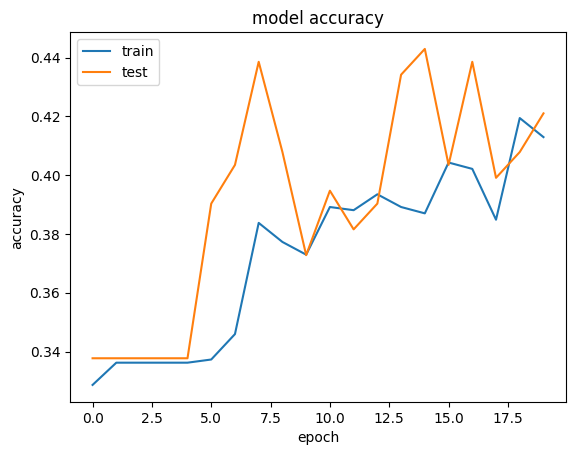

In [79]:
# plot the accuracy graph
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

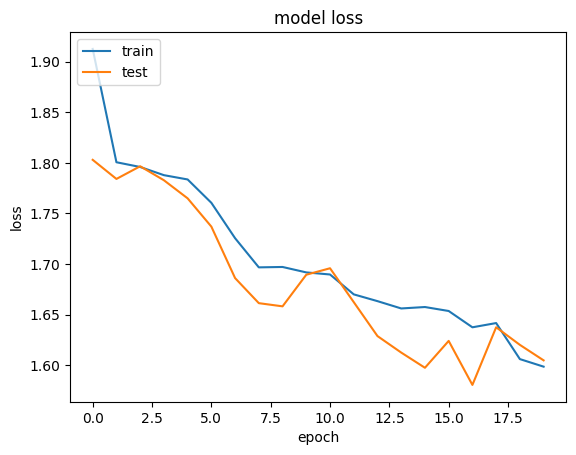

In [80]:
# loss graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [81]:
# save the model
model.save('boat_image_classification.keras')
print('model is saved')

model is saved


In [82]:
# load the keras model
from tensorflow.keras.models import load_model
model=load_model('boat_image_classification.keras')
print('model is loaded')

model is loaded


# Make Predictions

In [102]:
# Define a function to predict the probabilities of each of the 9 classes

def get_actual_predicted_labels(dataset):
  actual = [label for img, label in dataset.unbatch()]
  preds = model.predict(dataset)

  actual = tf.stack(actual, axis=0)
  predicted = tf.concat(preds, axis=0)
  predicted = tf.argmax(predicted, axis=1) # Select the class with the maximum probability as the final prediction

  return actual, predicted

In [103]:
# Use the function to get predicted probabilities on test data

actual, predictions = get_actual_predicted_labels(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 441ms/step


# Plot heatmap of the confusion matrix and print classification report.

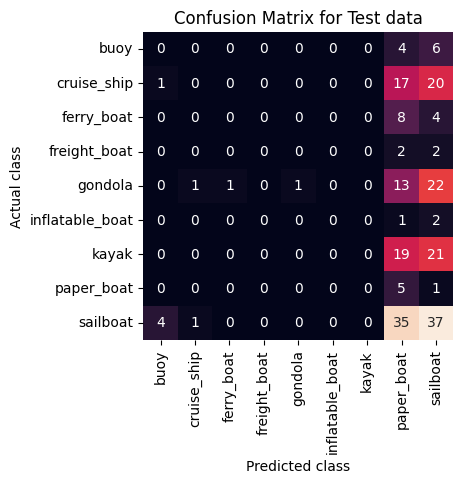

In [104]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Confusion matrix
cm = tf.math.confusion_matrix(actual, predictions)

plt.figure(figsize=(4,4))
ax = sns.heatmap(cm, annot=True, fmt='g', cbar=False)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
ax.xaxis.set_ticklabels(class_names)
ax.yaxis.set_ticklabels(class_names)

plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.title("Confusion Matrix for Test data")
plt.show()

1. We see that there are multiple boats that are incorrectly classified:
 - Cruise ship has been classified as sail boay 20 times
 - Sail boat has been classsified as paper boat 35 times

2. The model predicts paper boat and Sailboat maximum times which indicates that despite data augmentation, the class imbalance during training has likely caused the model to overfit.

In [105]:
# Classification Report

import warnings
import pandas as pd
warnings.filterwarnings('ignore')

print('Classification Report:\n')
pd.DataFrame(classification_report(actual, predictions, target_names=class_names, output_dict=True)).T

Classification Report:



,precision,recall,f1-score,support
buoy,0.000000,0.000000,0.000000,10.000000
cruise_ship,0.000000,0.000000,0.000000,38.000000
ferry_boat,0.000000,0.000000,0.000000,12.000000
freight_boat,0.000000,0.000000,0.000000,4.000000
gondola,1.000000,0.026316,0.051282,38.000000
inflatable_boat,0.000000,0.000000,0.000000,3.000000
kayak,0.000000,0.000000,0.000000,40.000000
paper_boat,0.048077,0.833333,0.090909,6.000000
sailboat,0.321739,0.480519,0.385417,77.000000
accuracy,0.188596,0.188596,0.188596,0.188596


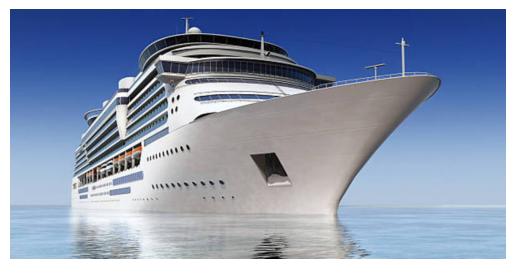

In [83]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img,img_to_array
import numpy as np

# Path to your new image
image_path = "/content/dataset-cover.jpg"

# Load the image
img = tf.keras.utils.load_img(image_path, target_size=(224, 224))

# Convert image to array
img_array = tf.keras.utils.img_to_array(img)

# Normalize the image
img_array = img_array / 255.0

# Add batch dimension (model expects a batch)
img_batch = np.expand_dims(img_array, axis=0)

#display image
test_image=load_img( "/content/dataset-cover.jpg" )
plt.imshow(test_image)
plt.axis('off')
plt.show()


In [84]:
# Predict on a single batch of images
pred = model.predict(img_batch)

# Get predicted class index
predicted_class_index = np.argmax(pred)
predicted_class_prob = pred[0][predicted_class_index]  # Probability of the predicted class

# Class names
class_names = ['buoy', 'cruise_ship', 'ferry_boat', 'freight_boat',
               'gondola', 'inflatable_boat', 'kayak', 'paper_boat', 'sailboat']

# Print result
print(f"Predicted class: {class_names[predicted_class_index]}")
print(f"Confidence: {predicted_class_prob:.2%}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
Predicted class: sailboat
Confidence: 43.52%


# Model 2.1: Build a CNN network using transfer learning
Build a CNN network using a lightweight pre-trained model as the first layer.

Lightweight models are good for deploying the solution on a mobile device using transfer learning. MobileNetV2 is a popular lightweight pre-trained model built using Keras API.

# Split Dataset (70:30)

In [85]:
import os
import random
import shutil
from tqdm import tqdm

# Parameters
original_dataset_dir = '/content/Automating Port Operations_Dataset/boat_type_classification_dataset'  # path to your current image folders
output_base_dir = '/content/Automating Port Operations_Dataset'     # new directory for train/val/test
split_ratio = (0.8, 0.2)  # train, test
seed = 43

# Ensure reproducibility
random.seed(seed)

# Create output folders
splits = ['train2', 'test2']
for split in splits:
    for class_name in os.listdir(original_dataset_dir):
        os.makedirs(os.path.join(output_base_dir, split, class_name), exist_ok=True)

# Split and copy files
for class_name in tqdm(os.listdir(original_dataset_dir), desc="Splitting dataset"):
    class_dir = os.path.join(original_dataset_dir, class_name)
    images = os.listdir(class_dir)
    random.shuffle(images)

    total = len(images)
    train_cut = int(split_ratio[0] * total)
    val_cut = int(split_ratio[1] * total)

    train_files = images[:train_cut]
    val_files = images[train_cut:train_cut + val_cut]
    test_files = images[train_cut + val_cut:]

    for split_name, file_list in zip(splits, [train_files, val_files, test_files]):
        for fname in file_list:
            src = os.path.join(class_dir, fname)
            dst = os.path.join(output_base_dir, split_name, class_name, fname)
            shutil.copy(src, dst)

print("Dataset split completed!")


Splitting dataset: 100%|██████████| 9/9 [00:00<00:00, 23.56it/s]

Dataset split completed!


In [86]:
train_path2 = '/content/Automating Port Operations_Dataset/train2'
test_path2 = '/content/Automating Port Operations_Dataset/test2'

train_ds2 = tf.keras.preprocessing.image_dataset_from_directory(
    train_path2,
    seed=43,
    shuffle=True,
    image_size=(224, 224),
    batch_size=32
)


test_ds2=tf.keras.preprocessing.image_dataset_from_directory(
    test_path2,
    seed=43,
    shuffle=True,
    image_size=(224,224),
    batch_size=32
)

Found 925 files belonging to 9 classes.
Found 228 files belonging to 9 classes.


In [87]:
925+228


1153

# Data Augmentation/ImageDataGenerator/Data Preprocessing

In [88]:
train_datagen=ImageDataGenerator(rescale=1./255,
                                 shear_range=0.2,
                                 zoom_range=0.2,
                                 width_shift_range=0.1,
                                height_shift_range=0.1,
                                 horizontal_flip=True)

test_datagen=ImageDataGenerator(rescale=1./255)

In [89]:
training_set=train_datagen.flow_from_directory(train_path2,
                                               target_size=(224,224),
                                               batch_size=32,
                                               class_mode='categorical')

test_set=test_datagen.flow_from_directory(test_path2,
                                          target_size=(224,224),
                                          batch_size=32,
                                          class_mode='categorical')

Found 925 images belonging to 9 classes.
Found 228 images belonging to 9 classes.


In [90]:
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout,GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import MobileNetV2

In [91]:
# Load MobileNetV2 as base (without top layer)
base_model = MobileNetV2(input_shape=(224, 224, 3),
                         include_top=False,
                         weights='imagenet')

In [92]:
# Freeze base model (don't train these layers)
base_model.trainable = False

In [93]:
# Build the model
model=Sequential()

model.add(base_model)

model.add(GlobalAveragePooling2D())
model.add(Dropout(0.2))

model.add(Dense(units=256,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Dense(units=128,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Dense(units=9,activation='softmax'))

In [94]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 9)                   │           1,161 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,621,513 (10.00 MB)

 Trainable params: 362,761 (1.38 MB)

 Non-trainable params: 2,258,752 (8.62 MB)

In [95]:
from tensorflow.keras.metrics import Precision, Recall

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)


In [96]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,             # Stop after 5 epochs with no improvement
    restore_best_weights=True
)

# Train the model
history = model.fit(
    training_set, # Use training_set instead of train_ds2
    validation_data=test_set, # Use test_set instead of test_ds2
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 37s 917ms/step - accuracy: 0.4736 - loss: 1.8407 - precision_3: 0.6317 - recall_3: 0.3375 - val_accuracy: 0.7368 - val_loss: 0.8338 - val_precision_3: 0.8152 - val_recall_3: 0.6579
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 542ms/step - accuracy: 0.8228 - loss: 0.6014 - precision_3: 0.8722 - recall_3: 0.7589 - val_accuracy: 0.8289 - val_loss: 0.5254 - val_precision_3: 0.8768 - val_recall_3: 0.7807
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 600ms/step - accuracy: 0.8835 - loss: 0.4055 - precision_3: 0.9321 - recall_3: 0.8254 - val_accuracy: 0.8246 - val_loss: 0.5077 - val_precision_3: 0.8829 - val_recall_3: 0.7939
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 597ms/step - accuracy: 0.9168 - loss: 0.3255 - precision_3: 0.9328 - recall_3: 0.8792 - val_accuracy: 0.8465 - val_loss: 0.4399 - val_precision_3: 0.9029 - val_recall_3: 0.8158
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 548ms/step - accuracy: 0.8904 - loss: 0.3323 - precision_3: 0.9229 - recall_3: 0.8

We have achieved a validation accuracy > 85% using the pretrained model
MobileNetv2.

Validation accuracy of the model that we created from scratch was 31%.

So far, the pre-trained model is faring better.

In [97]:
# Evaluate on test dataset
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_set)

print(f"\n Test Results:")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.8690 - loss: 0.4218 - precision_3: 0.9163 - recall_3: 0.8415

 Test Results:
Loss: 0.4030
Accuracy: 0.8684
Precision: 0.9223
Recall: 0.8333


On constructing a CNN from a pre-trained model we were able to achieve an accuracy of 86.84% on the test dataset.


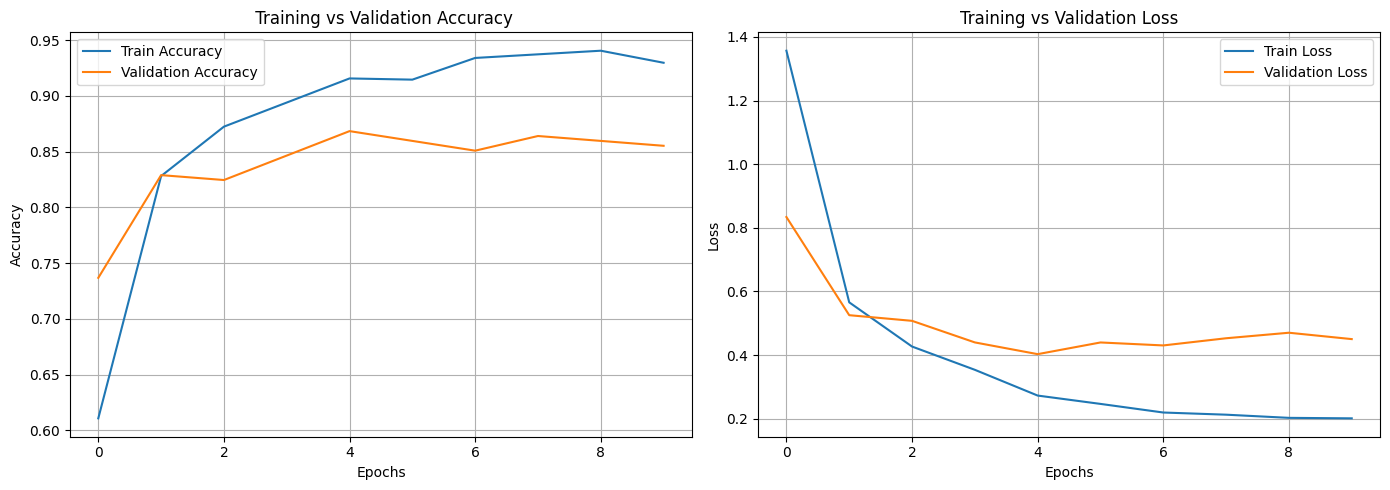

In [99]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title(' Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


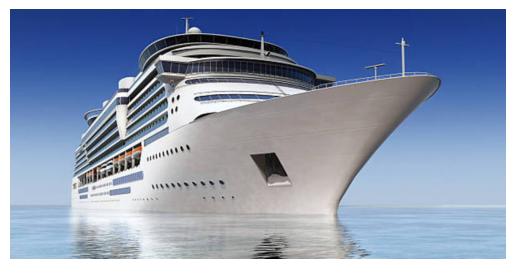

In [100]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img,img_to_array
import numpy as np

# Path to your new image
image_path = "/content/dataset-cover.jpg"

# Load the image
img = tf.keras.utils.load_img(image_path, target_size=(224, 224))

# Convert image to array
img_array = tf.keras.utils.img_to_array(img)

# Normalize the image
img_array = img_array / 255.0

# Add batch dimension (model expects a batch)
img_batch = np.expand_dims(img_array, axis=0)

#display image
test_image=load_img( "/content/dataset-cover.jpg" )
plt.imshow(test_image)
plt.axis('off')
plt.show()


In [101]:
# Predict on a single batch of images
pred = model.predict(img_batch)

# Get predicted class index
predicted_class_index = np.argmax(pred)
predicted_class_prob = pred[0][predicted_class_index]  # Probability of the predicted class

# Class names
class_names = ['buoy', 'cruise_ship', 'ferry_boat', 'freight_boat',
               'gondola', 'inflatable_boat', 'kayak', 'paper_boat', 'sailboat']

# Print result
print(f"Predicted class: {class_names[predicted_class_index]}")
print(f"Confidence: {predicted_class_prob:.2%}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted class: cruise_ship
Confidence: 97.28%


# Compare the results of both models built in steps 1 and 2 and state your observations.

# Observations:

  1.  Accuracy & Performance

* MobileNetV2 achieved higher test accuracy compared to the custom CNN.

2. Training Efficiency

* Custom CNN took more time to converge and showed signs of overfitting (train accuracy > val accuracy).


3. Generalization
* MobileNetV2 generalized better to unseen data (test set) with higher confidence and more accurate predictions.

* Custom CNN had lower confidence and struggled more with less represented classes.




# Insights:

Model 1 is great for learning and experimentation.

Model 2 is better for real-world use:

1. Faster

2. More accurate
